#라벨링해서 분류

/tmp/ipykernel_33523/41405807.py:51: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(data=subject_summary, x='Distance', y='Response_Right', hue='Force',


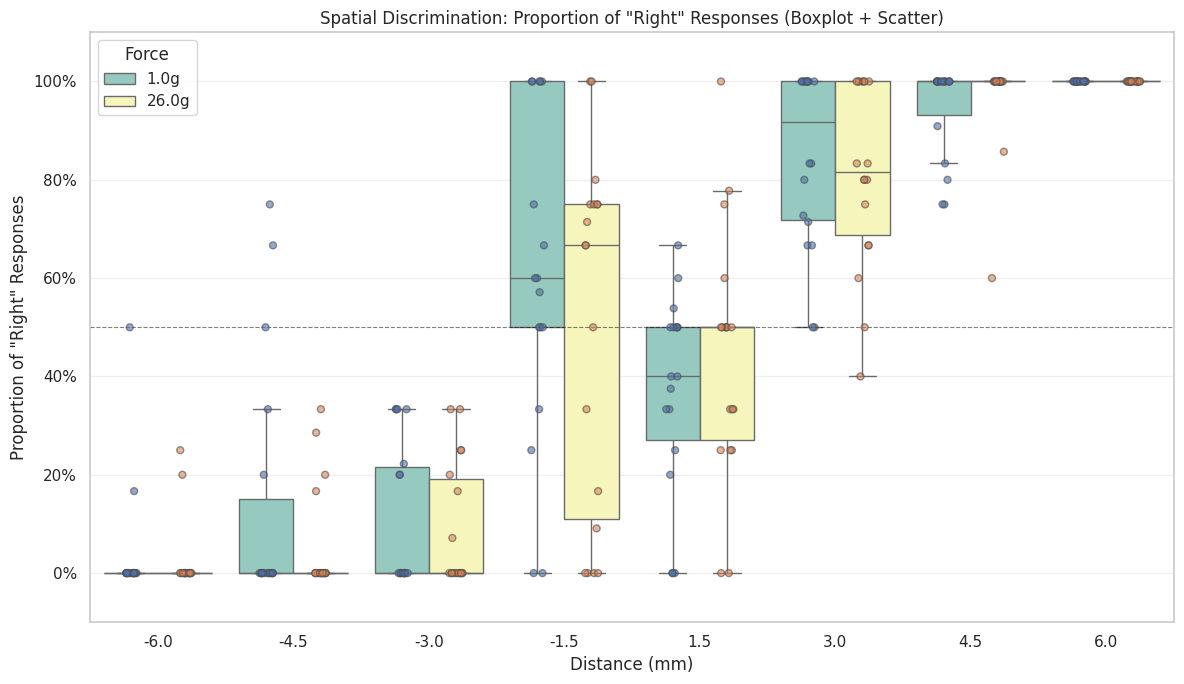


[Summary: Mean Proportion of 'Right' Response]
Distance      -6.0      -4.5      -3.0      -1.5       1.5       3.0  \
Force                                                                  
1.0g      0.039216  0.136111  0.108642  0.604202  0.366489  0.846753   
26.0g     0.025000  0.054762  0.089153  0.496585  0.437654  0.813889   

Distance       4.5   6.0  
Force                     
1.0g      0.946801   1.0  
26.0g     0.969841   1.0  


In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import glob

# 1. 데이터 로드 및 통합
file_pattern = 'P*_SpatialDiscrimination.csv'
file_list = glob.glob(file_pattern)

dist_map = {
    ('g0', 'g1'): 1.5,   ('g1', 'g0'): -1.5,
    ('g0', 'g-1'): -1.5, ('g-1', 'g0'): 1.5,
    ('g0', 'g2'): 3.0,   ('g2', 'g0'): -3.0,
    ('g0', 'g-2'): -3.0, ('g-2', 'g0'): 3.0,
    ('g0', 'g3'): 4.5,   ('g3', 'g0'): -4.5,
    ('g-3', 'g0'): 4.5,  ('g0', 'g-3'): -4.5,
    ('g0', 'g4'): 6.0,   ('g4', 'g0'): -6.0,
    ('g-4', 'g0'): 6.0,  ('g0', 'g-4'): -6.0,
    ('g0', 'g-14'): -6.0, ('g-14', 'g0'): 6.0
}

if not file_list:
    print("CSV 파일을 찾을 수 없습니다.")
else:
    all_data = []
    for file in file_list:
        df = pd.read_csv(file)
        all_data.append(df)

    combined_df = pd.concat(all_data, ignore_index=True)

    # 2. 거리 매핑 및 응답 수치화 ('Right' -> 1, 'Left' -> 0)
    combined_df['Distance'] = combined_df.apply(lambda row: dist_map.get((row['Stim_1st'], row['Stim_2nd']), None), axis=1)
    combined_df['Response_Right'] = combined_df['User_Response'].map({'Right': 1, 'Left': 0})
    combined_df = combined_df.dropna(subset=['Distance', 'Response_Right'])

    # 3. 피험자별/조건별 평균 계산
    # (각 피험자가 해당 거리에서 'Right'라고 답한 비율을 계산하여 Scatter 포인트로 사용)
    subject_summary = combined_df.groupby(['Subject', 'Force', 'Distance'])['Response_Right'].mean().reset_index()

    # 4. 시각화
    plt.figure(figsize=(12, 7))

    # 박스 플롯 (분포 표시)
    sns.boxplot(data=subject_summary, x='Distance', y='Response_Right', hue='Force',
                palette="Set3", showfliers=False)

    # 개별 데이터 포인트 (Scatter plot overlay)
    # dodge=True 옵션을 주어 박스 플롯의 hue 위치에 맞춰 점이 찍히게 합니다.
    sns.stripplot(data=subject_summary, x='Distance', y='Response_Right', hue='Force',
                  dodge=True, marker='o', alpha=0.6, edgecolor='gray', linewidth=1)

    # 범례 정리 (중복 제거)
    handles, labels = plt.gca().get_legend_handles_labels()
    unique_labels = len(subject_summary['Force'].unique())
    plt.legend(handles[0:unique_labels], labels[0:unique_labels], title='Force', loc='upper left')

    plt.title('Spatial Discrimination: Proportion of "Right" Responses (Boxplot + Scatter)')
    plt.xlabel('Distance (mm)')
    plt.ylabel('Proportion of "Right" Responses')
    plt.ylim(-0.1, 1.1)
    plt.axhline(0.5, color='black', linestyle='--', linewidth=0.8, alpha=0.5) # 50% 기준선
    plt.grid(True, axis='y', alpha=0.3)

    # Y축 퍼센트 포맷
    plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

    plt.tight_layout()
    plt.show()

    # 결과 요약 출력
    final_summary = subject_summary.groupby(['Force', 'Distance'])['Response_Right'].mean().unstack()
    print("\n[Summary: Mean Proportion of 'Right' Response]")
    print(final_summary)

#다른 버전인데 x축이 force임

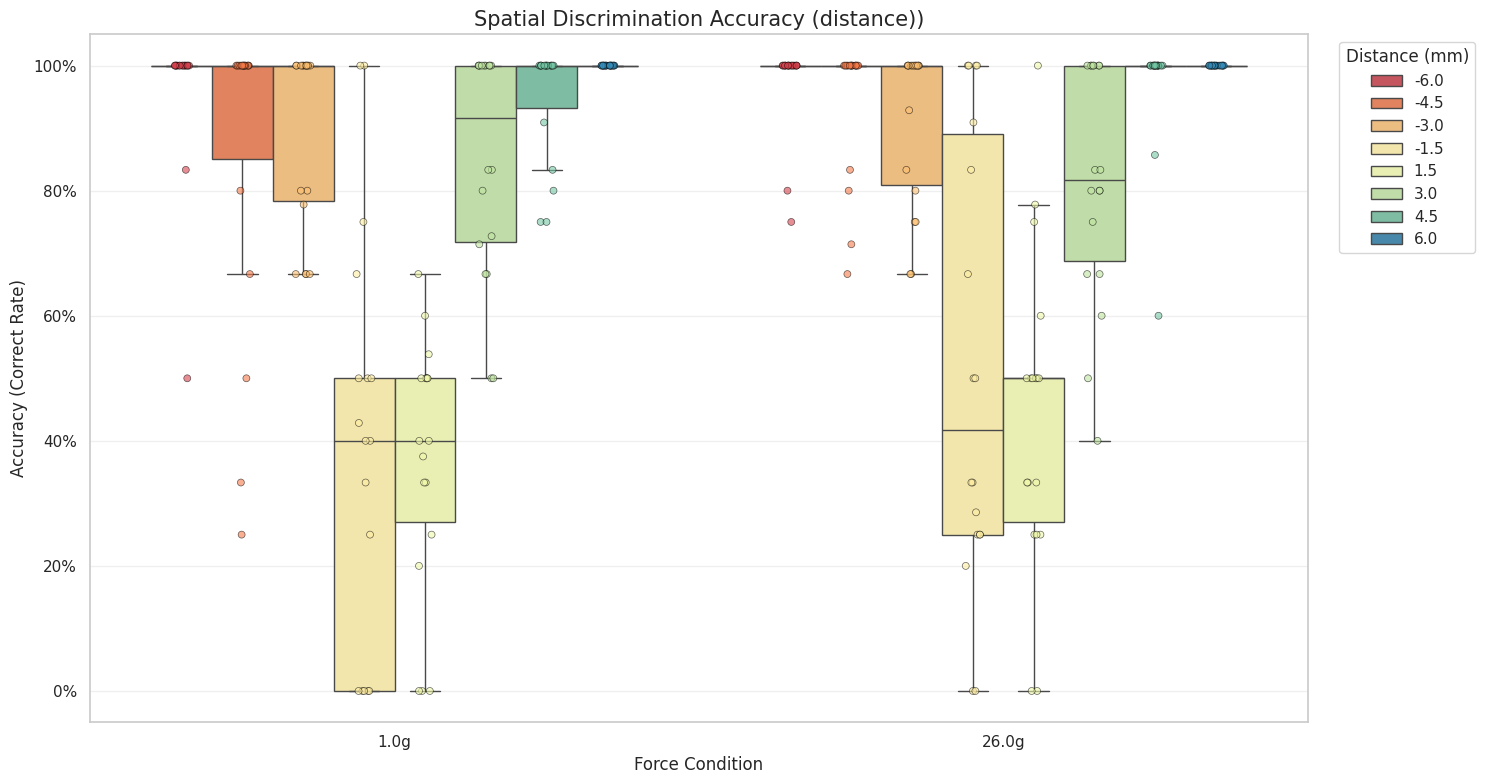

In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import glob

# 1. 데이터 로드 및 통합
file_pattern = 'P*_SpatialDiscrimination.csv'
file_list = glob.glob(file_pattern)

dist_map = {
    ('g0', 'g1'): 1.5,   ('g1', 'g0'): -1.5,
    ('g0', 'g-1'): -1.5, ('g-1', 'g0'): 1.5,
    ('g0', 'g2'): 3.0,   ('g2', 'g0'): -3.0,
    ('g0', 'g-2'): -3.0, ('g-2', 'g0'): 3.0,
    ('g0', 'g3'): 4.5,   ('g3', 'g0'): -4.5,
    ('g-3', 'g0'): 4.5,  ('g0', 'g-3'): -4.5,
    ('g0', 'g4'): 6.0,   ('g4', 'g0'): -6.0,
    ('g-4', 'g0'): 6.0,  ('g0', 'g-4'): -6.0,
    ('g0', 'g-14'): -6.0, ('g-14', 'g0'): 6.0
}

if not file_list:
    print("CSV 파일을 찾을 수 없습니다.")
else:
    all_data = []
    for file in file_list:
        df = pd.read_csv(file)
        all_data.append(df)
    combined_df = pd.concat(all_data, ignore_index=True)

    # 2. 데이터 전처리
    # dist_map을 사용하여 모든 시행에 Distance 값 할당
    combined_df['Distance'] = combined_df.apply(lambda row: dist_map.get((row['Stim_1st'], row['Stim_2nd']), None), axis=1)

    # 분석에 필요한 컬럼만 남기고 결측치 제거
    combined_df = combined_df.dropna(subset=['Distance'])

    # 3. 통계 계산: 피험자별/Force별/Distance(음수포함 전범위)별 정확도 평균
    # 각 피험자의 한 조건이 그래프 상의 하나의 '점'이 됩니다.
    subject_summary = combined_df.groupby(['Subject', 'Force', 'Distance'])['IsCorrect'].mean().reset_index()

    # 범례(Legend) 순서를 위해 Distance 정렬
    dist_list = sorted(subject_summary['Distance'].unique())
    # 모든 숫자를 라벨링 (예: -6.0, -4.5, ..., 6.0)
    subject_summary['Distance_Label'] = subject_summary['Distance'].astype(str)
    dist_labels = [str(d) for d in dist_list]

    # 4. 시각화 (X축: Force, Y축: Accuracy, Hue: 모든 Distance 라벨)
    plt.figure(figsize=(15, 8))

    # 박스 플롯 (모든 거리 라벨 표시)
    sns.boxplot(
        data=subject_summary,
        x='Force',
        y='IsCorrect',
        hue='Distance_Label',
        hue_order=dist_labels,
        palette='Spectral', # 다양한 라벨 구분을 위한 컬러 팔레트
        showfliers=False
    )

    # 개별 점 추가 (Scatter)
    sns.stripplot(
        data=subject_summary,
        x='Force',
        y='IsCorrect',
        hue='Distance_Label',
        hue_order=dist_labels,
        dodge=True,
        marker='o',
        alpha=0.6,
        edgecolor='black',
        linewidth=0.5,
        palette='Spectral'
    )

    # 범례 설정 (그래프 우측 외부 배치)
    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(handles[:len(dist_labels)], labels[:len(dist_labels)],
               title='Distance (mm)', bbox_to_anchor=(1.02, 1), loc='upper left')

    plt.title('Spatial Discrimination Accuracy (distance))', fontsize=15)
    plt.xlabel('Force Condition', fontsize=12)
    plt.ylabel('Accuracy (Correct Rate)', fontsize=12)

    # Y축 퍼센트 포맷팅 (0% ~ 100%)
    plt.ylim(-0.05, 1.05)
    plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

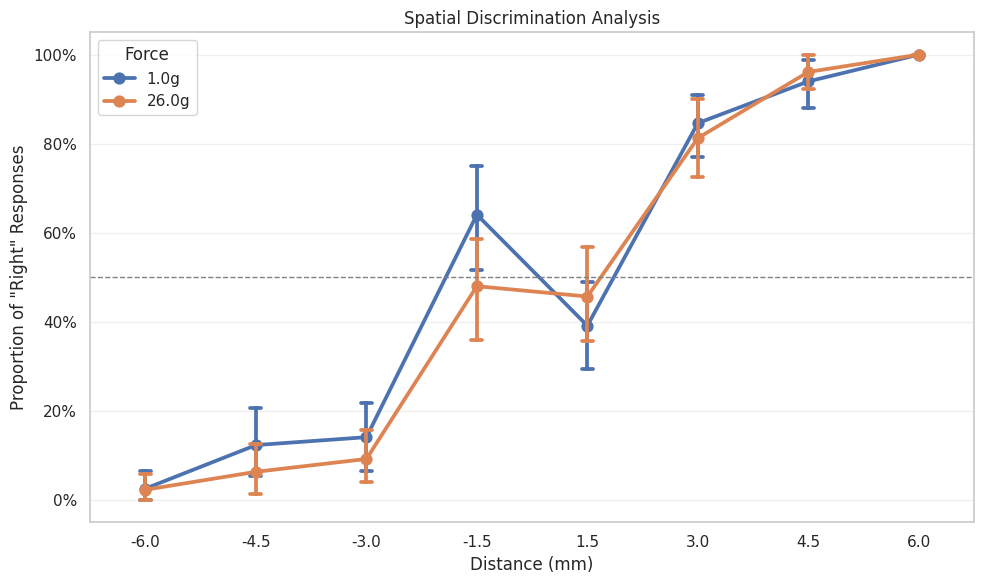


[Force 및 Distance별 'Right' 응답 확률 요약]
Distance      -6.0      -4.5      -3.0      -1.5       1.5       3.0  \
Force                                                                  
1.0g      0.025641  0.123288  0.141026  0.640625  0.391304  0.846154   
26.0g     0.022989  0.063291  0.092105  0.480000  0.456790  0.812500   

Distance       4.5   6.0  
Force                     
1.0g      0.939759   1.0  
26.0g     0.961039   1.0  

분석이 완료되었습니다. 'processed_spatial_discrimination.csv' 파일로 저장되었습니다.


In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import glob

# 1. 데이터 로드 및 통합
file_pattern = 'P*_SpatialDiscrimination.csv'
file_list = glob.glob(file_pattern)

dist_map = {
    ('g0', 'g1'): 1.5,   ('g1', 'g0'): -1.5,
    ('g0', 'g-1'): -1.5, ('g-1', 'g0'): 1.5,
    ('g0', 'g2'): 3.0,   ('g2', 'g0'): -3.0,
    ('g0', 'g-2'): -3.0, ('g-2', 'g0'): 3.0,
    ('g0', 'g3'): 4.5,   ('g3', 'g0'): -4.5,
    ('g-3', 'g0'): 4.5,  ('g0', 'g-3'): -4.5,
    ('g0', 'g4'): 6.0,   ('g4', 'g0'): -6.0,
    ('g-4', 'g0'): 6.0,  ('g0', 'g-4'): -6.0,
    ('g0', 'g-14'): -6.0, ('g-14', 'g0'): 6.0
}

if not file_list:
    print("CSV 파일을 찾을 수 없습니다.")
else:
    all_data = []
    for file in file_list:
        df = pd.read_csv(file)
        all_data.append(df)

    combined_df = pd.concat(all_data, ignore_index=True)

    # 2. 거리 매핑 (Distance mapping)
    combined_df['Distance'] = combined_df.apply(
        lambda row: dist_map.get((row['Stim_1st'], row['Stim_2nd']), None), axis=1
    )

    # 3. 응답 수치화 ('Right' -> 1, 'Left' -> 0)
    combined_df['Response_Right'] = combined_df['User_Response'].map({'Right': 1, 'Left': 0})

    # 분석을 위해 결측치(매핑되지 않은 쌍) 제거
    combined_df = combined_df.dropna(subset=['Distance', 'Response_Right'])

    # 4. 시각화 (Psychometric Curve)
    plt.figure(figsize=(10, 6))

    # Force별로 거리(Distance)에 따른 Right 응답 비율 계산 및 시각화
    sns.pointplot(data=combined_df, x='Distance', y='Response_Right', hue='Force',
                  markers='o', linestyles='-', capsize=.1)

    plt.title('Spatial Discrimination Analysis')
    plt.xlabel('Distance (mm)')
    plt.ylabel('Proportion of "Right" Responses')
    plt.ylim(-0.05, 1.05)
    plt.axhline(0.5, color='gray', linestyle='--', linewidth=1) # 50% 기준선
    plt.grid(True, axis='y', alpha=0.3)

    # Y축을 퍼센트(%) 형식으로 표시
    plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

    plt.tight_layout()
    plt.show()

    # 요약 결과 출력
    summary = combined_df.groupby(['Force', 'Distance'])['Response_Right'].mean().unstack()
    print("\n[Force 및 Distance별 'Right' 응답 확률 요약]")
    print(summary)

    # 처리된 데이터 저장
    combined_df.to_csv('processed_spatial_discrimination.csv', index=False)
    print("\n분석이 완료되었습니다. 'processed_spatial_discrimination.csv' 파일로 저장되었습니다.")

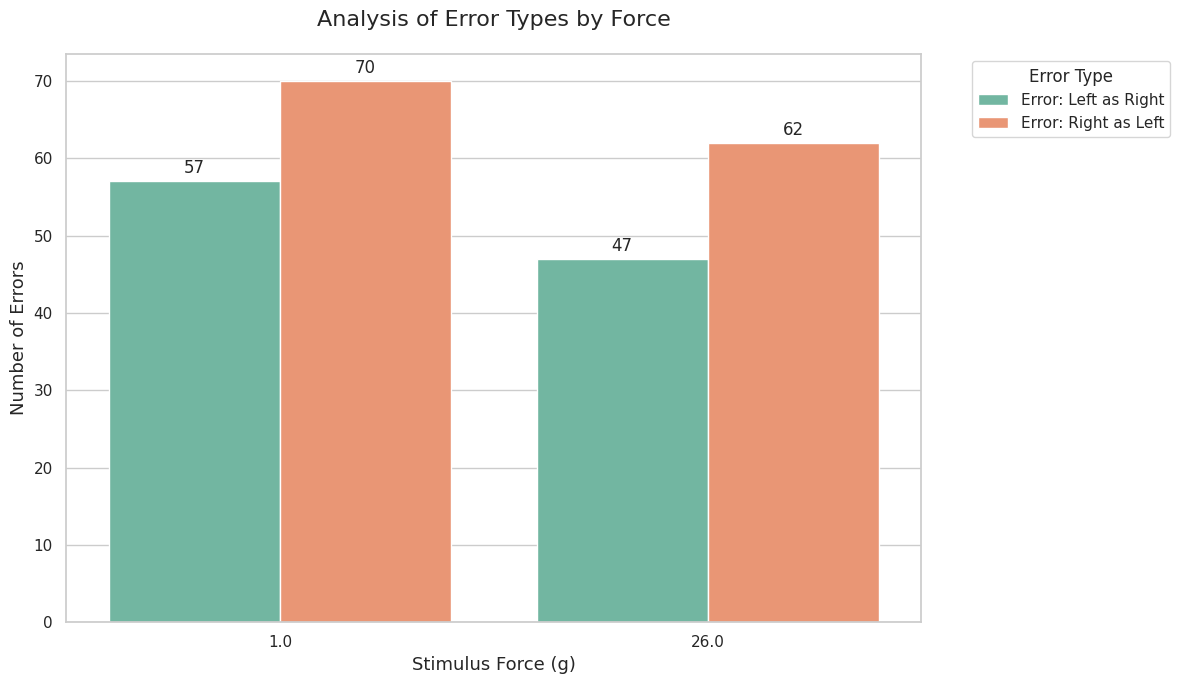


[오답 유형별 발생 횟수 요약]
Error_Type   Error: Left as Right  Error: Right as Left
Force_Value                                            
1.0                            57                    70
26.0                           47                    62


In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import glob

# 1. 데이터 로드 및 통합
file_pattern = 'P*_SpatialDiscrimination.csv'
file_list = glob.glob(file_pattern)

if not file_list:
    print("CSV 파일을 찾을 수 없습니다.")
else:
    df_list = [pd.read_csv(f) for f in file_list]
    df_merged = pd.concat(df_list, ignore_index=True)

    # 2. 데이터 전처리 및 오답 유형 정의
    # Force 숫자 추출
    if df_merged['Force'].dtype == 'object':
        df_merged['Force_Value'] = df_merged['Force'].str.replace('g', '').astype(float)
    else:
        df_merged['Force_Value'] = df_merged['Force']

    # Label 추출 및 -4, -3 제외
    df_merged['Label'] = df_merged['Comparison_Target'].str.replace('g', '').astype(int)
    df_filtered = df_merged[~df_merged['Label'].isin([-4, -3])].copy()

    # 오답 유형 분류 함수
    def classify_error(row):
        if row['IsCorrect'] == 1:
            return 'Correct'
        elif row['Target_Response'] == 'Left' and row['User_Response'] == 'Right':
            return 'Error: Left as Right'
        elif row['Target_Response'] == 'Right' and row['User_Response'] == 'Left':
            return 'Error: Right as Left'
        else:
            return 'Other Error'

    df_filtered['Error_Type'] = df_filtered.apply(classify_error, axis=1)

    # 3. 오답 발생 빈도 계산 (Error 케이스만 추출)
    error_only = df_filtered[df_filtered['Error_Type'].str.contains('Error')].copy()

    # Force별로 각 오답 유형이 몇 번 발생했는지 카운트
    error_counts = error_only.groupby(['Force_Value', 'Error_Type']).size().reset_index(name='Count')

    # 4. 시각화 (오답 유형 분석)
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(12, 7))

    ax = sns.barplot(
        data=error_counts,
        x='Force_Value',
        y='Count',
        hue='Error_Type',
        palette='Set2'
    )

    # 막대 위에 숫자 표시
    for container in ax.containers:
        ax.bar_label(container, padding=3)

    # 그래프 디테일 설정
    plt.title('Analysis of Error Types by Force', fontsize=16, pad=20)
    plt.xlabel('Stimulus Force (g)', fontsize=13)
    plt.ylabel('Number of Errors', fontsize=13)
    plt.legend(title='Error Type', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

    # 5. 요약 데이터 출력 (표 형태)
    print("\n[오답 유형별 발생 횟수 요약]")
    summary = error_counts.pivot(index='Force_Value', columns='Error_Type', values='Count').fillna(0)
    print(summary)

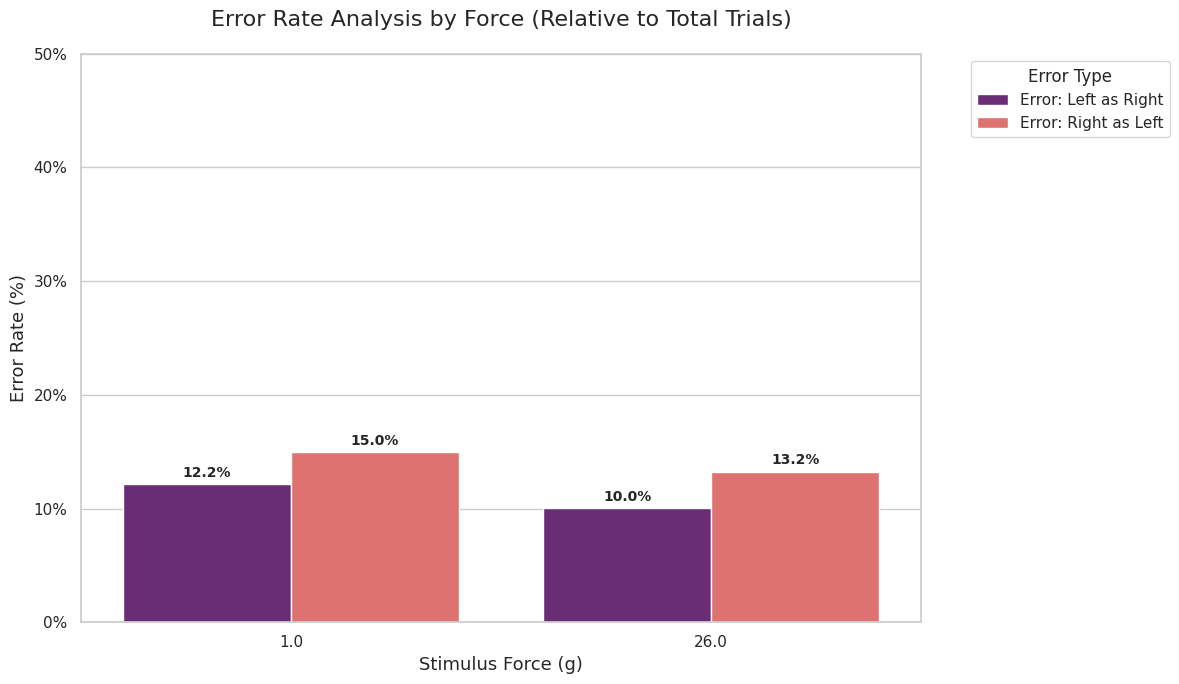


[Force별 오답 비율(%) 요약]
Error_Type   Error: Left as Right  Error: Right as Left
Force_Value                                            
1.0                     12.179487             14.957265
26.0                    10.042735             13.247863


In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import glob

# 1. 데이터 로드 및 통합
file_pattern = 'P*_SpatialDiscrimination.csv'
file_list = glob.glob(file_pattern)

if not file_list:
    print("CSV 파일을 찾을 수 없습니다.")
else:
    df_list = [pd.read_csv(f) for f in file_list]
    df_merged = pd.concat(df_list, ignore_index=True)

    # 2. 데이터 전처리
    df_merged['Force_Value'] = df_merged['Force'].str.replace('g', '').astype(float)
    df_merged['Label'] = df_merged['Comparison_Target'].str.replace('g', '').astype(int)
    df_filtered = df_merged[~df_merged['Label'].isin([-4, -3])].copy()

    # 오답 유형 분류
    def classify_error(row):
        if row['IsCorrect'] == 1:
            return 'Correct'
        elif row['Target_Response'] == 'Left' and row['User_Response'] == 'Right':
            return 'Error: Left as Right'
        elif row['Target_Response'] == 'Right' and row['User_Response'] == 'Left':
            return 'Error: Right as Left'
        else:
            return 'Other Error'

    df_filtered['Error_Type'] = df_filtered.apply(classify_error, axis=1)

    # 3. 오답 비율(Rate) 계산
    # Force별 전체 시행 횟수 계산
    total_counts = df_filtered.groupby('Force_Value').size().reset_index(name='Total_Trials')

    # Force별 오답 유형별 횟수 계산
    error_counts = df_filtered.groupby(['Force_Value', 'Error_Type']).size().reset_index(name='Count')

    # 데이터 병합 및 비율 계산
    error_analysis = pd.merge(error_counts, total_counts, on='Force_Value')
    error_analysis['Error_Rate'] = error_analysis['Count'] / error_analysis['Total_Trials']

    # 오답 유형만 추출 (Correct 제외)
    error_plot_df = error_analysis[error_analysis['Error_Type'].str.contains('Error')].copy()

    # 4. 시각화 (오답 비율 분석)
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(12, 7))

    ax = sns.barplot(
        data=error_plot_df,
        x='Force_Value',
        y='Error_Rate',
        hue='Error_Type',
        palette='magma'
    )

    # 막대 위에 비율(%) 표시
    for container in ax.containers:
        labels = [f'{v*100:.1f}%' for v in container.datavalues]
        ax.bar_label(container, labels=labels, padding=3, fontsize=10, fontweight='bold')

    # 그래프 디테일 설정
    plt.title('Error Rate Analysis by Force (Relative to Total Trials)', fontsize=16, pad=20)
    plt.xlabel('Stimulus Force (g)', fontsize=13)
    plt.ylabel('Error Rate (%)', fontsize=13)
    plt.ylim(0, max(error_plot_df['Error_Rate'].max() * 1.2, 0.5)) # 여백 확보

    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    plt.legend(title='Error Type', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

    # 요약 데이터 출력
    print("\n[Force별 오답 비율(%) 요약]")
    summary = error_plot_df.pivot(index='Force_Value', columns='Error_Type', values='Error_Rate').fillna(0)
    print(summary * 100) # 퍼센트로 출력